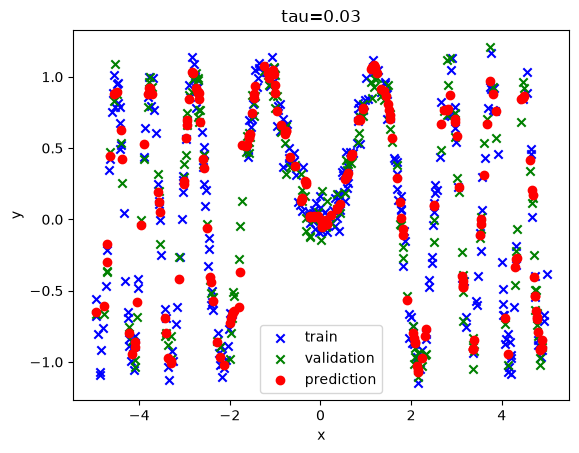

mse is 0.014917965531061571


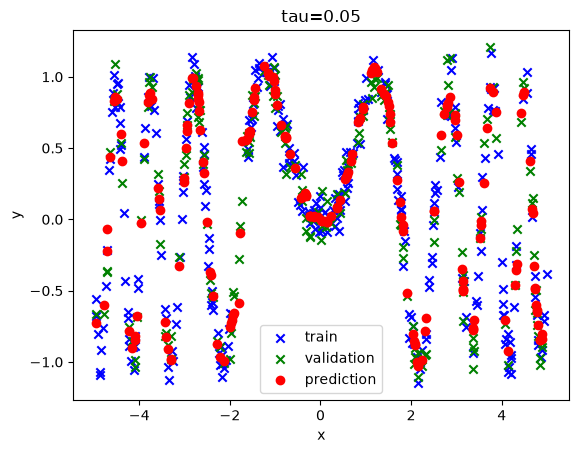

mse is 0.014526460867830113


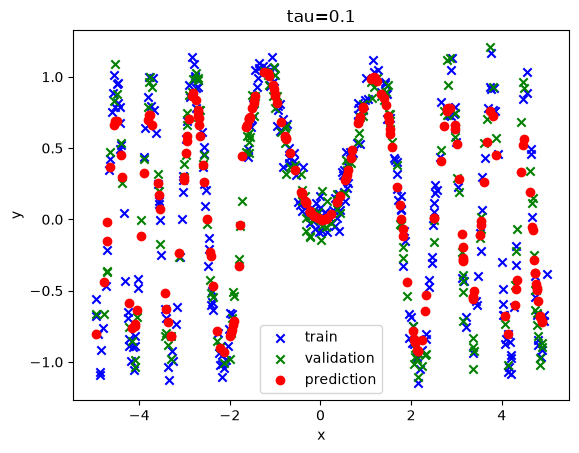

mse is 0.030014916708401326


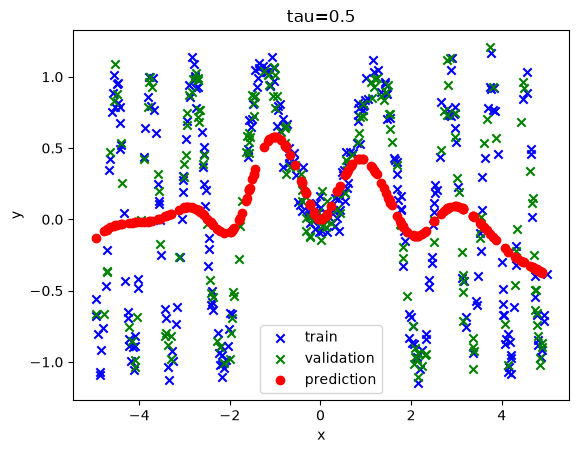

mse is 0.3365507639747307


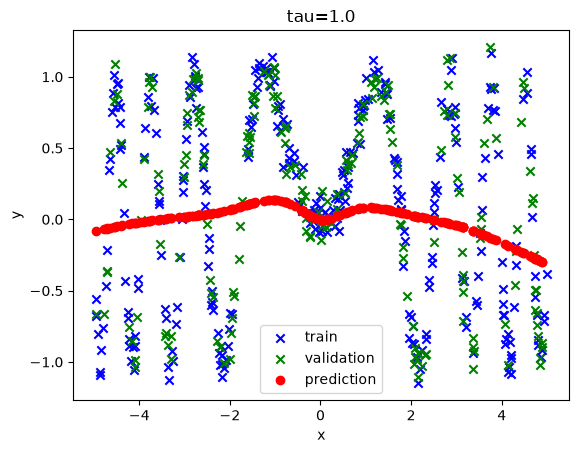

mse is 0.4227979108589323


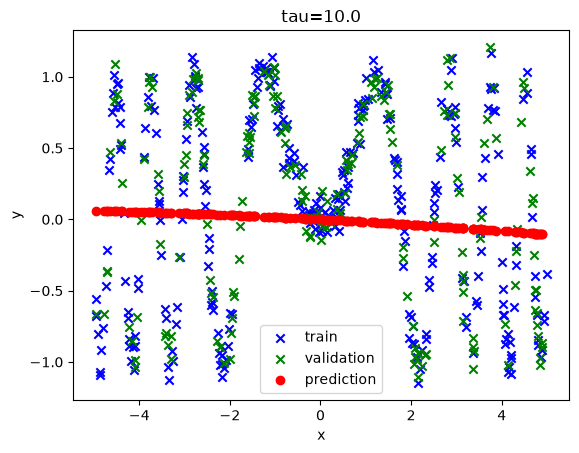

mse is 0.45166472958615095


In [6]:
import os

import matplotlib.pyplot as plt
import numpy as np

def read_csv(path):
    with open(path,'r') as file:
        headers=file.readline().strip().split(',')

    x_cols=[i for i in range(len(headers)) if headers[i].startswith('x')]
    y_cols=[i for i in range(len(headers)) if headers[i].startswith('y')]

    inputs=np.loadtxt(path,delimiter=',',skiprows=1,usecols=x_cols)
    labels=np.loadtxt(path,delimiter=',',skiprows=1,usecols=y_cols)

    if inputs.ndim==1:
        inputs=inputs.reshape(-1,1)
    
    if labels.ndim==1:
        labels=labels.reshape(-1,1)

    return inputs,labels

class LocallyWeightedLinearRegression:
    def __init__(self,train_inputs,train_labels,val_inputs,val_labels,tau):
        self.train_inputs=train_inputs
        self.train_labels=train_labels
        self.val_inputs=val_inputs
        self.val_labels=val_labels
        self.theta=None
        self.tau=tau

    def predict(self):
        predictions=[]
        for x in self.val_inputs:
            distances=np.linalg.norm(self.train_inputs-x,axis=1)
            weights=np.diag(np.exp(-distances**2/(2*self.tau**2)))
            prediction=np.linalg.inv(self.train_inputs.T @ weights @ self.train_inputs) @ self.train_inputs.T @ weights @ self.train_labels @ x
            predictions.append(prediction)
        return predictions

    def calculate_mse(self):
        predictions=self.predict()
        predictions=np.array(predictions).reshape(-1,1)
        # mse=np.mean((self.val_labels-predictions)**2)
        mse=(np.linalg.norm(predictions-self.val_labels))**2/len(predictions)
        return mse

def main(tau_values, train_path, valid_path, test_path, pred_path):
    train_inputs,train_labels=read_csv(train_path)
    val_inputs,val_labels=read_csv(valid_path)

    mse_best=None
    tau_best=None
    for tau in tau_values:
        lwr=LocallyWeightedLinearRegression(train_inputs,train_labels,val_inputs,val_labels,tau)
        predictions=lwr.predict()
        fig=plt.figure()
        plt.scatter(train_inputs,train_labels,c='b',marker='x',label='train')
        plt.scatter(val_inputs,val_labels,c='g',marker='x',label='validation')
        plt.scatter(val_inputs,predictions,c='r',marker='o',label='prediction')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend()
        plt.title(f"tau={tau}")
        save_plot(fig,tau)
        plt.show()
        mse=lwr.calculate_mse()
        print("mse is",mse)
        if mse_best is None or mse<mse_best:
            mse=mse_best
            tau_best=tau

def save_plot(fig, tau):
    plot_dir='plot'
    if not os.path.exists(plot_dir):
        os.makedirs(plot_dir)
    fig_path=os.path.join(plot_dir,f'tau={tau}.png')
    fig.savefig(fig_path,dpi=300)

if __name__ == '__main__':
    main(tau_values=[3e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1],
         train_path='./train.csv',
         valid_path='./valid.csv',
         test_path='./test.csv',
         pred_path='./pred.txt')
